# Scoping Review Analysis

Figures for the scoping review of spatio-temporal models of infectious disease. Styled after *The Economist*'s illustration conventions:

- Red flag tag + figure label at top-left
- Bold black title, grey deck (subtitle)
- Horizontal gridlines only, no box
- Curated 6-colour palette
- Source line along the bottom

All figures are written to **`exported_figures/`** as 300-dpi PNGs.

In [49]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

from review_plot_helpers import (
    FIG_DIR,
    ECON,
    TIME_RESOLUTION_ORDER,
    HORIZON_BAND_ORDER,
    METHOD_FAMILY_ORDER,
    code_bucket,
    configure_matplotlib,
    econ_axes,
    economist_frame,
    extract_countries,
    normalize_disease,
    prepare_time_features,
)

configure_matplotlib()


## Load the workbook

In [50]:
EXCEL_PATH = Path("Scoping_review_notes_on_papers.xlsx")
assert EXCEL_PATH.exists(), EXCEL_PATH
df_main = pd.read_excel(EXCEL_PATH, sheet_name="Sheet1")
df_arch = pd.read_excel(EXCEL_PATH, sheet_name="Model Architecture")
df_cov = pd.read_excel(EXCEL_PATH, sheet_name="Covariates")
df_eval = pd.read_excel(EXCEL_PATH, sheet_name="Evaluation & Performance")
df_interp = pd.read_excel(EXCEL_PATH, sheet_name="Interpretation")
df_temporal = pd.read_excel(EXCEL_PATH, sheet_name="Temporal evolution methods")

def included(df, col_candidates=("Included", "Included?")):
    for c in col_candidates:
        if c in df.columns:
            return df[df[c].astype(str).str.strip().str.lower().isin(["yes", "y"])].copy()
    return df.copy()

df_main = included(df_main)
df_arch = included(df_arch)
df_cov = included(df_cov)
df_eval = included(df_eval)
df_interp = included(df_interp)

ARCH_COL = "Core model (LSTM / GNN / Transformer / Hybrid)"
tev = df_arch.dropna(subset=["year", ARCH_COL]).copy()
tev["year"] = tev["year"].astype(int)

print(f"Included papers: {len(df_main)}")
print(f"Architecture : {len(df_arch)}")
print(f"Covariates : {len(df_cov)}")
print(f"Evaluation : {len(df_eval)}")
print(f"Interpretation : {len(df_interp)}")
print(f"Arch rows used : {len(tev)}")


Included papers: 93
Architecture : 93
Covariates : 93
Evaluation : 93
Interpretation : 93
Arch rows used : 93


## Publication volume over time
A simple column chart of papers per year with the COVID-19 inflection annotated.

saved → /Users/oc25003/scoping-review-figures/exported_figures/fig1_publications_by_year.png


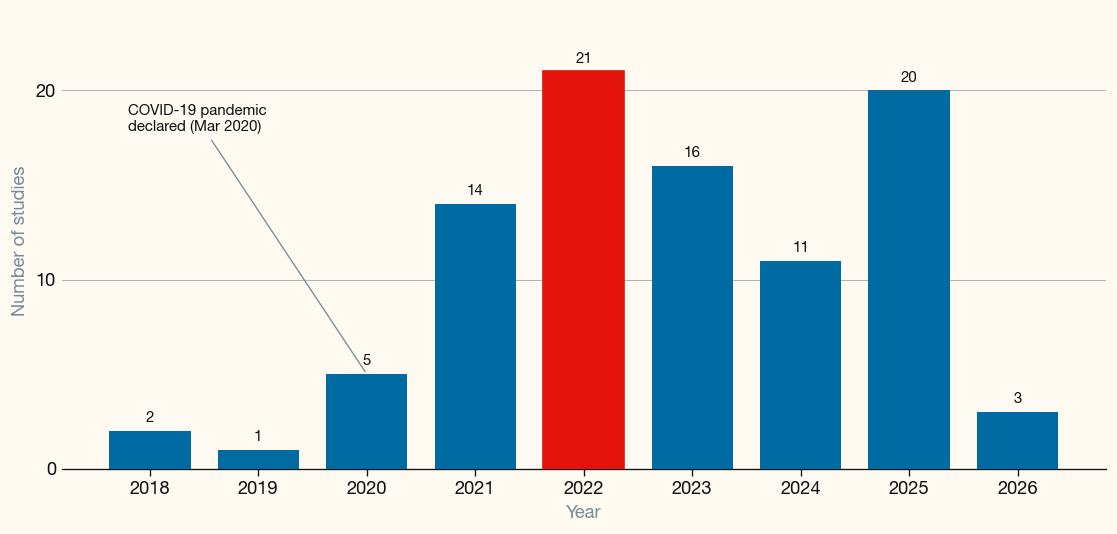

In [51]:
yr = (df_main["year"].dropna().astype(int).value_counts().sort_index())
yr = yr.reindex(range(int(yr.index.min()), int(yr.index.max()) + 1), fill_value=0)

fig = plt.figure(figsize=(10, 5.6))
ax = fig.add_axes([0.08, 0.14, 0.87, 0.68])
bars = ax.bar(yr.index.astype(str), yr.values, color=ECON["navy"], width=0.75, zorder=3)

# highlight the peak year in red
peak = int(yr.idxmax())
for bar, year in zip(bars, yr.index):
    if year == peak:
        bar.set_color(ECON["red"])

# value labels on top
for bar in bars:
    h = bar.get_height()
    if h > 0:
        ax.text(bar.get_x() + bar.get_width() / 2, h + max(yr.values) * 0.015,
                f"{int(h)}", ha="center", va="bottom", fontsize=9,
                color=ECON["ink"])

# COVID-19 annotation
if 2020 in yr.index:
    x20 = list(yr.index).index(2020)
    ax.annotate("COVID-19 pandemic\ndeclared (Mar 2020)",
                xy=(x20, yr.loc[2020]),
                xytext=(x20 - 2.2, max(yr.values) * 0.85),
                fontsize=9, color=ECON["ink"],
                arrowprops=dict(arrowstyle="-", color=ECON["grey"], lw=0.8))


ax.set_ylabel("Number of studies", color=ECON["grey"])
ax.set_xlabel("Year", color=ECON["grey"])
ax.set_ylim(0, max(yr.values) * 1.15)
ax.set_yticks(np.arange(0, max(yr.values) * 1.15, 10))
econ_axes(ax)

_out = FIG_DIR / "fig1_publications_by_year.png"
fig.savefig(_out)
print(f"saved → {_out.resolve()}")
plt.show()


## Which diseases are studied
Horizontal bar chart ordered by frequency, Economist-style value labels at end of bars.

19 unique disease labels
Disease
COVID-19                           59
Dengue                             10
Influenza                           6
ILI                                 4
Tuberculosis                        3
Chickenpox                          3
Crimean-Congo Haemorhagic fever     2
Zika                                2
Influenza and COVID-19              2
Hand, foot and mouth disease        1
Cholera                             1
Malaria                             1
Measles                             1
Ebola                               1
Influenza like illness              1
Salmonella                          1
West Nile neuroinvasive disease     1
Chikungunya                         1
Influenza -like-illness             1
Name: count, dtype: int64
saved → /Users/oc25003/scoping-review-figures/exported_figures/fig2_disease_breakdown.png


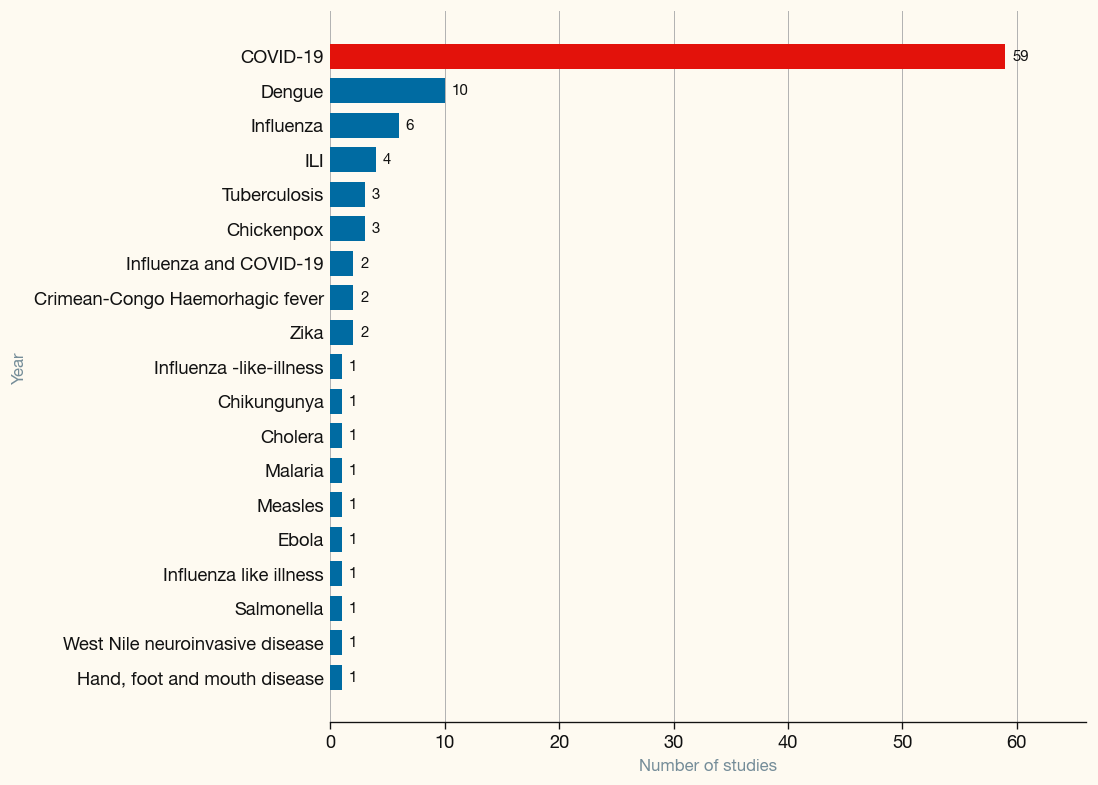

In [82]:
dis = df_main["Disease"].fillna("").astype(str)

dis_protected = dis.str.replace(
    "Hand, foot and mouth disease",
    "Hand§ foot and mouth disease",  
    regex=False
)

dis_counts = (
    dis_protected.str.split(r"\s*,\s*")
       .explode()
       .str.strip()
       .str.replace("§", ",", regex=False)   # restore the real commas
       .value_counts()
)
print(len(dis_counts), "unique disease labels")
print(dis_counts)

top = dis_counts.sort_values()

fig = plt.figure(figsize=(10, 8))
ax = fig.add_axes([0.32, 0.10, 0.63, 0.74])

colors = [ECON["red"] if d == top.idxmax() else ECON["navy"] for d in top.index]
ax.barh(top.index, top.values, color=colors, zorder=3, height=0.72)

for i, (d, v) in enumerate(top.items()):
    ax.text(v + max(top.values) * 0.01, i, f"{int(v)}",
            va="center", ha="left", fontsize=9, color=ECON["ink"])

ax.set_xlim(0, max(top.values) * 1.12)
ax.set_xlabel("Number of studies", fontsize=10, color=ECON["grey"])
ax.set_ylabel("Year", fontsize=10, color=ECON["grey"])
econ_axes(ax, grid_axis="x")
ax.tick_params(axis="y", pad=4)


_out = FIG_DIR / "fig2_disease_breakdown.png"
fig.savefig(_out)
print(f"saved → {_out.resolve()}")
plt.show()


## Study location — country / region

Horizontal bar chart of the countries covered by the included studies. Many papers cover more than one country, so we count each country mentioned in the `Region` field.


In [83]:
# full country table (papers counted once per country) 
country_series = df_main["Region"].apply(extract_countries)

# de-dupe within a paper, but still count a paper toward BOTH countries
# if it studied multiple locations
flat = [c for sub in country_series for c in set(sub)]
country_counts = pd.Series(flat).value_counts()

n_papers = len(df_main)

tbl = (
    country_counts
    .rename_axis("Country")
    .reset_index(name="Papers")
)
tbl["% of papers"] = (tbl["Papers"] / n_papers * 100).round(0).astype(int)
tbl.insert(0, "Rank", range(1, len(tbl) + 1))

print(tbl.to_string(index=False))
print(f"\n{len(tbl)} countries across {n_papers} papers "
      f"(percentages sum to >100% because papers can cover multiple countries)")


 Rank               Country  Papers  % of papers
    1                   USA      36           39
    2                 Italy      11           12
    3                 Japan      10           11
    4                 China       9           10
    5                    UK       9           10
    6                 Spain       8            9
    7                Brazil       6            6
    8 Global / multi-region       4            4
    9                France       4            4
   10                 India       3            3
   11               Germany       3            3
   12               Hungary       3            3
   13               Türkiye       2            2
   14             Sri Lanka       2            2
   15                Taiwan       2            2
   16             Indonesia       2            2
   17             Australia       2            2
   18           Netherlands       2            2
   19                  Iran       1            1
   20               

## Forecast horizon bands

Bar chart grouping each study by its longest forecast horizon: short (up to 2 weeks), medium (2-4 weeks), or longer-term (>4 weeks).


In [84]:
df_time = prepare_time_features(df_main)

In [85]:
from review_plot_helpers import parse_horizon_days

def horizon_band(days):
    if pd.isna(days):
        return "Not reported"
    elif days <= 7:
        return "1 week"
    elif days <= 28:
        return "1–4 weeks"
    else:
        return "4+ weeks"

df_time["forecast_horizon_days"] = (
    df_time["Forecast horizon"].apply(parse_horizon_days)
)

df_time["forecast_horizon_band"] = (
    df_time["forecast_horizon_days"].apply(horizon_band)
)

print(df_time["forecast_horizon_band"].value_counts())

forecast_horizon_band
1–4 weeks       30
4+ weeks        27
1 week          25
Not reported    11
Name: count, dtype: int64


forecast_horizon_band
1–4 weeks       30
4+ weeks        27
1 week          25
Not reported    11
Name: count, dtype: int64
saved -> /Users/oc25003/scoping-review-figures/exported_figures/fig_forecast_horizon_bands.png


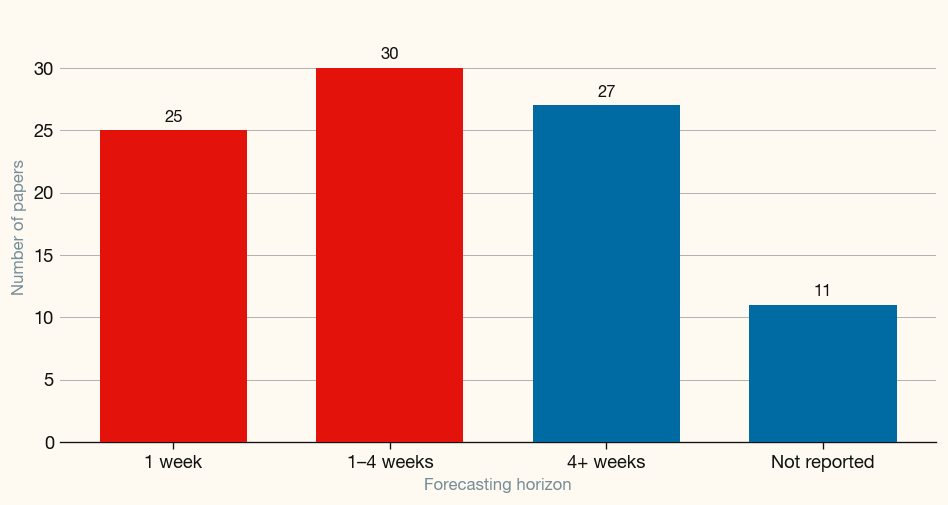

forecast_horizon_band
1–4 weeks       30
4+ weeks        27
1 week          25
Not reported    11
Name: count, dtype: int64


In [97]:
HORIZON_BAND_ORDER = ["1 week", "1–4 weeks", "4+ weeks", "Not reported"]

horizon_band_counts = (
    df_time["forecast_horizon_band"]
    .value_counts()
    .reindex(HORIZON_BAND_ORDER, fill_value=0)
)

df_time["forecast_horizon_days"] = (
    df_time["Forecast horizon"]
    .apply(parse_horizon_days)
)

def horizon_band(days):
    if pd.isna(days):
        return "Not reported"
    elif days <= 7:
        return "1 week"
    elif days <= 28:
        return "1–4 weeks"
    else:
        return "4+ weeks"

df_time["forecast_horizon_band"] = (
    df_time["forecast_horizon_days"]
    .apply(horizon_band)
)

print(df_time["forecast_horizon_band"].value_counts())

fig = plt.figure(figsize=(8.8, 5.6))
ax = fig.add_axes([0.10, 0.16, 0.83, 0.64])

# Highlight short horizons in red
colors = [
    ECON["red"] if k in ["1 week", "1–4 weeks"] else ECON["navy"]
    for k in horizon_band_counts.index
]

bars = ax.bar(
    horizon_band_counts.index,
    horizon_band_counts.values,
    color=colors,
    width=0.68,
    zorder=3,
)

ymax = horizon_band_counts.max()

for bar in bars:
    h = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        h + ymax * 0.015,
        f"{int(h)}",
        ha="center",
        va="bottom",
        fontsize=10,
        color=ECON["ink"],
    )

ax.set_ylim(0, ymax * 1.15)
ax.set_xlabel("")
ax.set_ylabel("Number of papers", fontsize=10, color=ECON["grey"])
ax.set_xlabel("Forecasting horizon", fontsize=10, color=ECON["grey"])

econ_axes(ax, grid_axis="y")

_out = FIG_DIR / "fig_forecast_horizon_bands.png"
fig.savefig(_out, dpi=300, bbox_inches="tight")

print(f"saved -> {_out.resolve()}")

plt.show()

print(df_time["forecast_horizon_band"].value_counts())


## Method category over time
Stacked-area chart of method families by publication year.

                       Family  Appearances
0            LSTM / GRU / RNN           43
1                         GNN           36
2                   CNN-based           20
3        Hybrid / mechanistic           17
4  Classical ML / statistical           16
5     Transformer / attention            9
6    Probabilistic / Bayesian            8
7                       Other            4
Year
2018    0
2019    0
2020    0
2021    0
2022    3
2023    3
2024    4
2025    7
2026    0
dtype: int64
4 rows landed in 'Other'

Core model (LSTM / GNN / Transformer / Hybrid)
Generative adversarial network          1
Radial basis function neural network    1
Psuedogrouping adversarial ML           1
Neural network                          1
Year
2018    0
2019    0
2020    0
2021    0
2022    2
2023    2
2024    0
2025    4
2026    1
dtype: int64


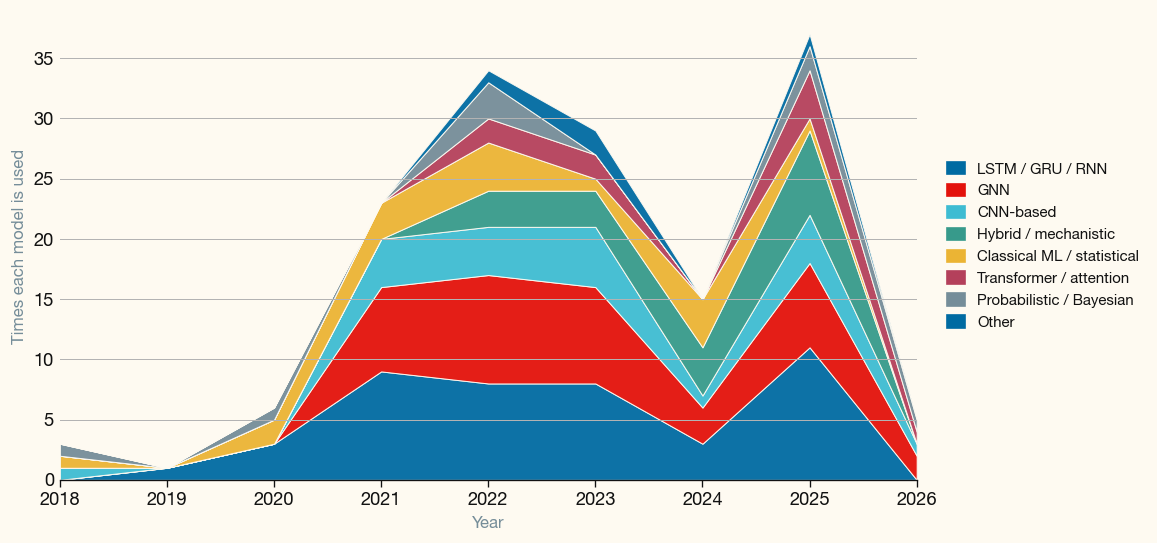

In [118]:
METHOD_FAMILY_KEYWORDS = {
    "Hybrid / mechanistic": ["hybrid", "sir", "seir", "compartment", "mechanistic",
                             "physics informed", "pinn", "ising"],
    "GNN": ["graph", "gnn", "gcn", "gat", "mpnn"],
    "Transformer / attention": ["transformer", "attention", "mamba", "state space", "peformer"],
    "LSTM / GRU / RNN": ["lstm", "gru", "rnn", "recurrent", "seq2seq", "sequence to sequence"],
    "CNN-based": ["cnn", "convolution", "u-net", "encoder-decoder", "resnet", "encoderdecodermodel"],
    "Probabilistic / Bayesian": ["bayesian", "gaussian process", "probabilistic", "inla"],
    "Classical ML / statistical": ["random forest", "xgboost", "gradient", "svm", "lasso", "glm",
                                   "regression", "arima", "sarima", "naive bayes", "naïve bayes", "symbolic", "autoregressive chains"],
}

def method_families(raw):
    if pd.isna(raw):
        return ["Other"]
    text = str(raw).strip().lower()
    hits = [fam for fam, kws in METHOD_FAMILY_KEYWORDS.items() if any(k in text for k in kws)]
    if "GNN" in hits and "transformer" not in text and "mamba" not in text:
        hits = [h for h in hits if h != "Transformer / attention"]
    return hits or ["Other"]

ARCH_COL = "Core model (LSTM / GNN / Transformer / Hybrid)"

tev = df_arch.dropna(subset=["year", ARCH_COL]).copy()
tev["Year"] = tev["year"].astype(int)                      
tev["Category"] = tev[ARCH_COL].apply(method_families)   
tev = tev.explode("Category")                              # one row per (paper, family) → totals can exceed 93
tev["Category"] = tev["Category"].astype(str).str.strip()

# Pivot: rows = year, cols = category, values = count
pivot = (tev.groupby(["Year", "Category"]).size()
             .unstack(fill_value=0)
             .sort_index())

# ensure continuous years (int() guards against float index)
pivot = pivot.reindex(range(int(pivot.index.min()), int(pivot.index.max()) + 1),
                      fill_value=0)

# rank by total size so bigger categories sit at the bottom
order = pivot.sum().sort_values(ascending=False).index.tolist()
pivot = pivot[order]

cat_colors = [ECON[c] for c in ["navy", "red", "cyan", "teal", "gold", "plum", "grey"]]
cat_colors = (cat_colors * ((len(order) // len(cat_colors)) + 1))[:len(order)]

fig = plt.figure(figsize=(10.5, 6))
ax = fig.add_axes([0.08, 0.16, 0.68, 0.65])
ax.stackplot(pivot.index, pivot.T.values, labels=pivot.columns,
             colors=cat_colors, edgecolor=ECON["paper"], linewidth=0.6, alpha=0.95)
ax.set_xlim(pivot.index.min(), pivot.index.max())
ax.set_xticks(pivot.index)
ax.tick_params(axis="x", rotation=0)
ax.set_ylabel("Times each model is used", fontsize=10, color=ECON["grey"])
ax.set_xlabel("Year", fontsize=10, color=ECON["grey"])
econ_axes(ax, grid_axis="y")

# legend outside right
handles = [Rectangle((0, 0), 1, 1, color=c) for c in cat_colors]
ax.legend(handles, pivot.columns, loc="center left", bbox_to_anchor=(1.02, 0.5),
          fontsize=9, handlelength=1.2, handleheight=0.9, labelcolor=ECON["ink"])

counts = tev["Category"].value_counts().rename_axis("Family").reset_index(name="Appearances")
print(counts)

hybrid_by_year = (tev[tev["Category"] == "Hybrid / mechanistic"]
                  .groupby("Year").size()
                  .reindex(range(int(tev["Year"].min()), int(tev["Year"].max()) + 1), fill_value=0))
print(hybrid_by_year)

# Show the raw core-model strings that matched no family
other = tev.loc[tev["Category"] == "Other", ARCH_COL]
print(f"{len(other)} rows landed in 'Other'\n")
print(other.value_counts(dropna=False).to_string())


transformer_by_year = (tev[tev["Category"] == "Transformer / attention"]
                  .groupby("Year").size()
                  .reindex(range(int(tev["Year"].min()), int(tev["Year"].max()) + 1), fill_value=0))
print(transformer_by_year)

## Data/co-variates used in the included studies


In [128]:
import re
from collections import Counter

cov = df_cov.copy()
other = cov["Other"].dropna().astype(str)

# rough tally of recurring themes by keyword, not exact strings
THEMES = {
    "Geographic coords / shapefiles": ["latitude", "longitude", "coordinate", "shapefile", "altitude", "geographic"],
    "Hospitalisation / clinical": ["hospital", "icu", "emergency dept", "medical claim", "death", "recovery", "recovered"],
    "Vaccination": ["vaccin"],
    "Mask / NPI behaviour": ["mask", "physical distan", "social distan", "lockdown"],
    "Search / social media": ["google", "search", "social media", "twitter"],
    "Land use / built env": ["land use", "building", "urban", "vegetation", "environment"],
    "Population density": ["population", "density", "birth rate"],
    "Mobile / phone data": ["mobile phone", "phone data", "mobility"],
    "Surveillance / case detail": ["surveillance", "incidence", "infection rate"],
}

other = cov["Other"].dropna().astype(str)
other = other[~other.str.strip().isin(["0", "0.0", ""])]   # drop blanks and literal zeros

theme_counts = Counter()
for raw in other:
    t = raw.lower()
    for theme, kws in THEMES.items():
        if any(k in t for k in kws):
            theme_counts[theme] += 1

for theme, n in theme_counts.most_common():
    print(f"{n:3d}  {theme}")

# the genuinely unclassifiable remainder
unmatched = [r for r in other if not any(
    any(k in r.lower() for k in kws) for kws in THEMES.values())]
print("\nstill 'other':", len(unmatched))
for r in unmatched:
    print("   ", r)


 13  Hospitalisation / clinical
 12  Geographic coords / shapefiles
  7  Land use / built env
  5  Surveillance / case detail
  5  Population density
  4  Vaccination
  3  Search / social media
  3  Mask / NPI behaviour
  1  Mobile / phone data

still 'other': 9
    Geolocated case counts
    Distances of states/counties to target
    Adjacency between regions
    COVID symptom survey
    Social connectedness data
    Emergency department visits
    Proximity between regions
    Spatial influence from neighbouring states
    Interactions between regions


## Covariates used
Horizontal bar chart of how often each covariate family is used.

saved → /Users/oc25003/scoping-review-figures/exported_figures/fig5_covariates.png


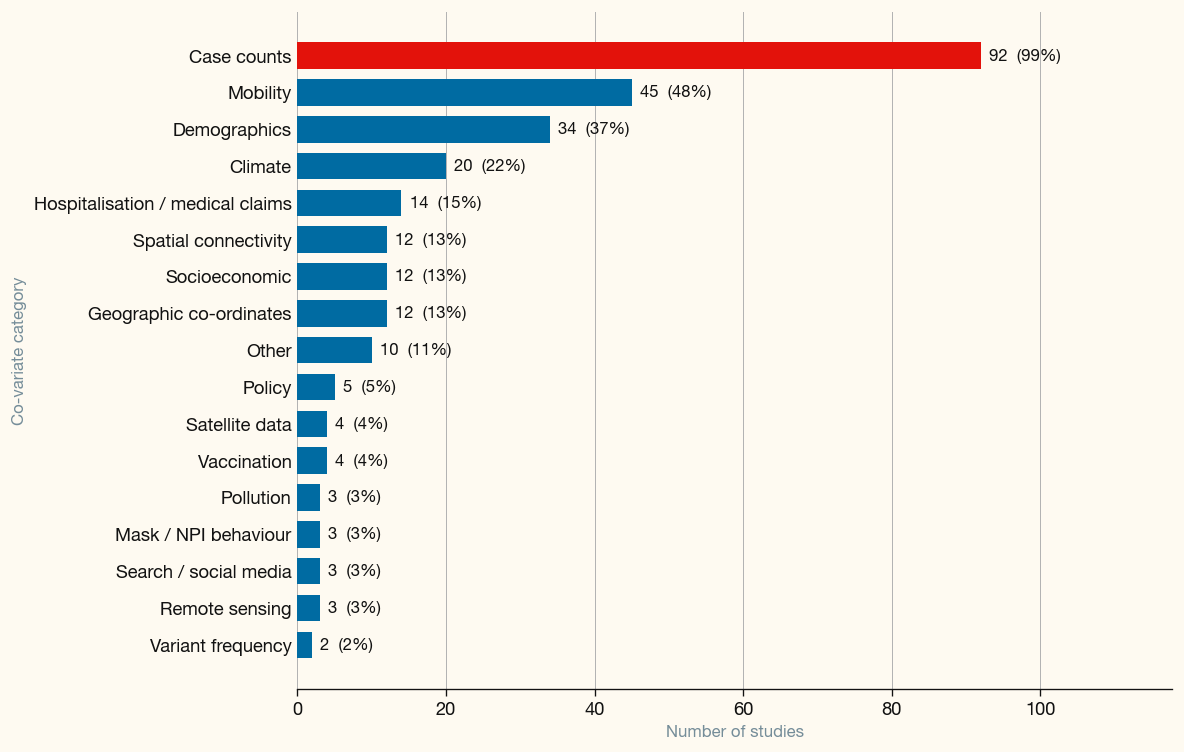

In [145]:
cov_cols = ["Case counts", "Mobility", "Climate", "Pollution",
            "Socioeconomic", "Policy", "Variant frequency",
            "Satellite data", "Remote sensing", "Demographics"]

missing = [c for c in cov_cols if c not in df_cov.columns]
if missing:
    print(f"WARNING: these columns were not found and will be skipped: {missing}")
cov_present = [c for c in cov_cols if c in df_cov.columns]

OTHER_THEMES = {
    "Hospitalisation / medical claims": ["hospital", "icu", "emergency dep", "death", "recover",
                                         "medical claim", "clinical"],
    "Geographic co-ordinates": ["latitude", "longitude", "coordinate", "altitude",
                                         "shapefile", "geographic"],
    "Vaccination": ["vaccin"],
    "Mask / NPI behaviour": ["mask", "physical distan", "social distan", "lockdown"],
    "Search / social media": ["google", "search", "social media", "twitter"],
    "Spatial connectivity": ["neighbour", "neighbor", "adjacen", "proximity",
                                         "distance to", "distances of", "nearby",
                                         "spatial influence", "interactions between regions",
                                         "connectedness"],
}

# count columns defined in excel
counts = {}
for c in cov_present:
    counts[c] = int(pd.to_numeric(df_cov[c], errors="coerce").fillna(0).sum())

# count free text in "other" excel column 
other_txt = df_cov["Other"].fillna("").astype(str).str.strip().str.lower()
other_txt = other_txt.where(~other_txt.isin(["", "0", "0.0"]), "")  

matched_any = pd.Series(False, index=other_txt.index)  

# detect population mentions in Other and promote to Demographics
pop_in_other = other_txt.apply(     
    lambda t: bool(t) and any(k in t for k in ["population", "pop density", "population density"])
)

# add to Demographics only where the flag wasn't already set
demo_flag = pd.to_numeric(df_cov["Demographics"], errors="coerce").fillna(0).astype(bool)
counts["Demographics"] += int((pop_in_other & ~demo_flag).sum())
matched_any |= pop_in_other                             # now safe to use both

# count remaining themes
for theme, kws in OTHER_THEMES.items():
    hit = other_txt.apply(lambda t: bool(t) and any(k in t for k in kws))
    counts[theme] = int(hit.sum())
    matched_any |= hit

# residual Other = had text but matched nothing
residual = (other_txt != "") & (~matched_any)
counts["Other"] = int(residual.sum())

# plot
cov_counts = pd.Series(counts).sort_values()
n_papers = len(df_cov)

fig, ax = plt.subplots(figsize=(10, 6.4))
colors = [ECON["red"] if v == cov_counts.max() else ECON["navy"]
          for v in cov_counts.values]
ax.barh(cov_counts.index, cov_counts.values, color=colors, height=0.72, zorder=3)
for i, (k, v) in enumerate(cov_counts.items()):
    pct = v / n_papers * 100
    ax.text(v + max(cov_counts.values) * 0.012, i,
            f"{int(v)}  ({pct:.0f}%)", va="center", ha="left",
            fontsize=10, color=ECON["ink"])
ax.set_xlim(0, max(cov_counts.values) * 1.28)
ax.set_xlabel("Number of studies", fontsize=10, color=ECON["grey"])
ax.set_ylabel("Co-variate category", fontsize=10, color=ECON["grey"])
econ_axes(ax, grid_axis="x")
plt.tight_layout()

_out = FIG_DIR / "fig5_covariates.png"
fig.savefig(_out, dpi=300, bbox_inches="tight")
print(f"saved → {_out.resolve()}")
plt.show()


## Evaluation metrics reported

saved → /Users/oc25003/scoping-review-figures/exported_figures/fig6_evaluation_metrics.png


/var/folders/4t/swtm73jj1k59sn2zwrw8k69h0000gp/T/ipykernel_50261/4115972042.py:62: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


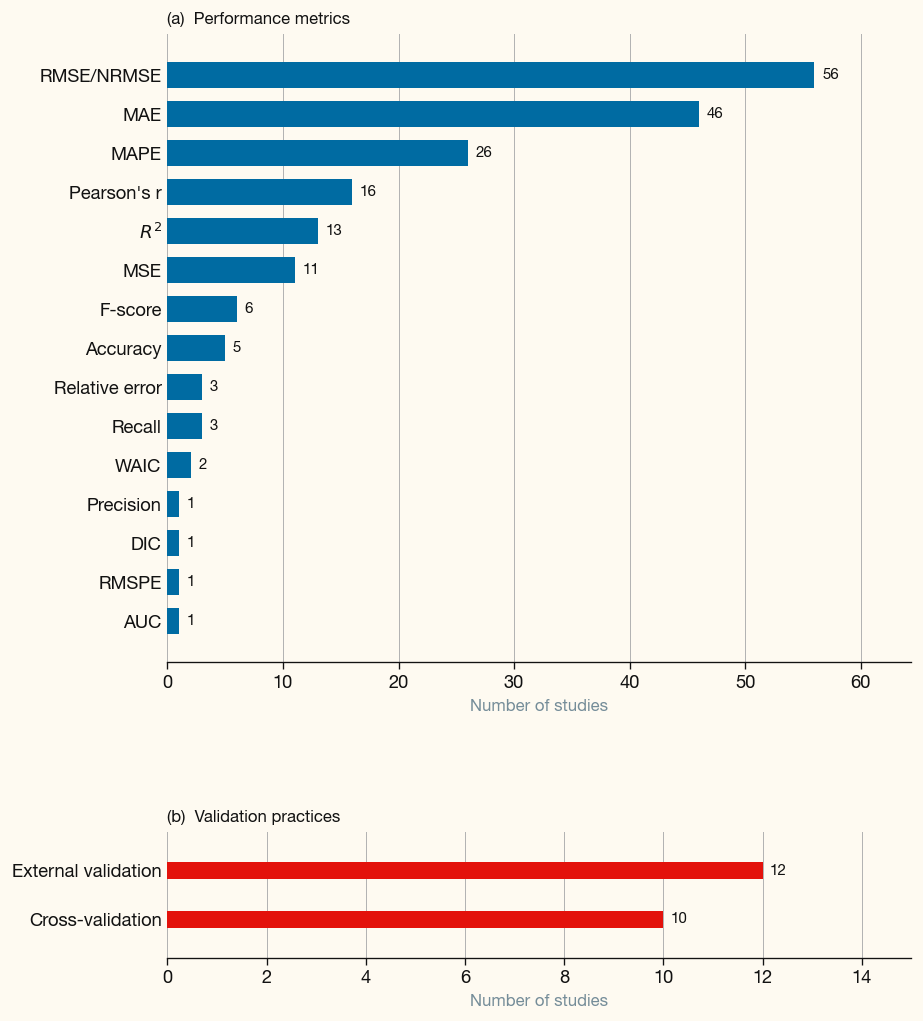

In [174]:
metric_cols = ["RMSE/NRMSE", "MAE", "MAPE", "AUC", "Cross-validation?",
               "External validation?",
               "R2", "F-score", "RMSPE", "Pearsons",
               "Watanabe Akaike information criterion",
               "Deviance information criterion",
               "Precision", "Recall", "Accuracy", "Relative error", "MSE"]

pretty_rename = {
    "Cross-validation?": "Cross-validation",
    "External validation?": "External validation",
    "Watanabe Akaike information criterion": "WAIC",
    "Deviance information criterion": "DIC",
    "Pearsons": "Pearson's r",
    "R2": "$R^2$",
}

validation_cols = {"Cross-validation", "External validation"}

metric_present = [c for c in metric_cols if c in df_eval.columns]
metric_counts = (df_eval[metric_present].apply(pd.to_numeric, errors="coerce")
                                         .fillna(0).astype(int).sum())
metric_counts.index = [pretty_rename.get(c, c) for c in metric_counts.index]

val_counts  = metric_counts[metric_counts.index.isin(validation_cols)].sort_values()
perf_counts = metric_counts[~metric_counts.index.isin(validation_cols)].sort_values()

n_eval = len(df_eval)

fig, (ax_perf, ax_val) = plt.subplots(
    2, 1,
    figsize=(8, 10),
    gridspec_kw={"height_ratios": [len(perf_counts), len(val_counts) + 1],
                 "hspace": 0.45},
)

# (a) performance metrics
ax_perf.barh(perf_counts.index, perf_counts.values,
             color=ECON["navy"], height=0.65, zorder=3)
for i, (k, v) in enumerate(perf_counts.items()):
    ax_perf.text(v + max(perf_counts.values) * 0.012, i, f"{int(v)}",
                 va="center", ha="left", fontsize=9, color=ECON["ink"])
ax_perf.set_xlim(0, max(perf_counts.values) * 1.15)
ax_perf.set_xlabel("Number of studies", fontsize=10, color=ECON["grey"])
ax_perf.set_title("(a)  Performance metrics", fontsize=10, fontweight="bold",
                  loc="left", pad=6, color=ECON["ink"])
econ_axes(ax_perf, grid_axis="x")

# (b) validation practices
val_color = ECON.get("red")
ax_val.barh(val_counts.index, val_counts.values,
            color=val_color, height=0.35, zorder=3)   # thinner bars for only 2 items
for i, (k, v) in enumerate(val_counts.items()):
    ax_val.text(v + max(val_counts.values) * 0.012, i, f"{int(v)}",
                va="center", ha="left", fontsize=9, color=ECON["ink"])
ax_val.set_xlim(0, max(val_counts.values) * 1.25)
ax_val.set_xlabel("Number of studies", fontsize=10, color=ECON["grey"])
ax_val.set_title("(b)  Validation practices", fontsize=10, fontweight="bold",
                 loc="left", pad=6, color=ECON["ink"])
ax_val.set_ylim(-0.8, len(val_counts) - 0.2)          # tighten y so bars aren't tiny
econ_axes(ax_val, grid_axis="x")

plt.tight_layout()

_out = FIG_DIR / "fig6_evaluation_metrics.png"
fig.savefig(_out, dpi=300, bbox_inches="tight")
print(f"saved → {_out.resolve()}")
plt.show()

## Interpretation and downstream use

saved → /Users/oc25003/scoping-review-figures/exported_figures/fig8_transparency.png


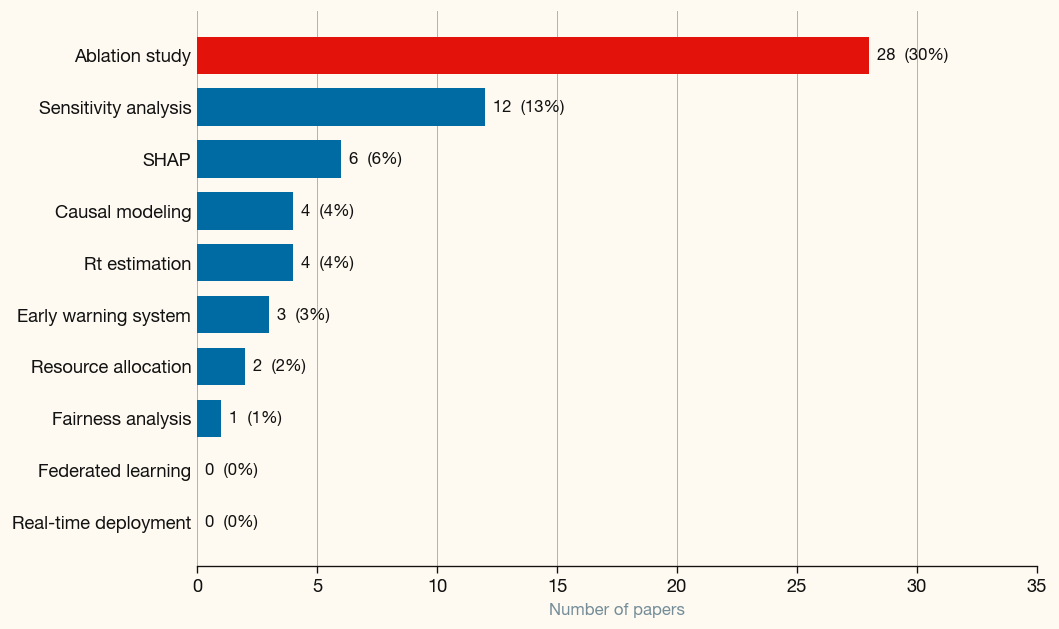

In [181]:
interp_cols = ["SHAP", "Sensitivity analysis", "Rt estimation", "Causal modeling",
                "Early warning system", "Resource allocation", "Real-time deployment",
                "Federated learning", "Fairness analysis", "Ablation study "]
present = [c for c in interp_cols if c in df_interp.columns]
counts = (df_interp[present].apply(pd.to_numeric, errors="coerce")
                             .fillna(0).astype(int).sum())
counts.index = [c.strip() for c in counts.index]
counts = counts.sort_values()
n = len(df_interp)

fig = plt.figure(figsize=(10, 6.6))
ax = fig.add_axes([0.24, 0.12, 0.70, 0.70])
colors = [ECON["red"] if v == counts.max() else ECON["navy"] for v in counts.values]
ax.barh(counts.index, counts.values, color=colors, height=0.72, zorder=3)
for i, (k, v) in enumerate(counts.items()):
    pct = v / n * 100
    ax.text(v + max(counts.values) * 0.012, i, f"{int(v)}  ({pct:.0f}%)",
            va="center", ha="left", fontsize=10, color=ECON["ink"])

ax.set_xlim(0, max(counts.values) * 1.25)
ax.set_xlabel("Number of papers", fontsize=10, color=ECON["grey"])
econ_axes(ax, grid_axis="x")

fig.savefig(_out)
print(f"saved → {_out.resolve()}")
plt.show()


## Code availability
Donut chart for code availability (URL / repository link = available).

saved → /Users/oc25003/scoping-review-figures/exported_figures/fig8_transparency.png


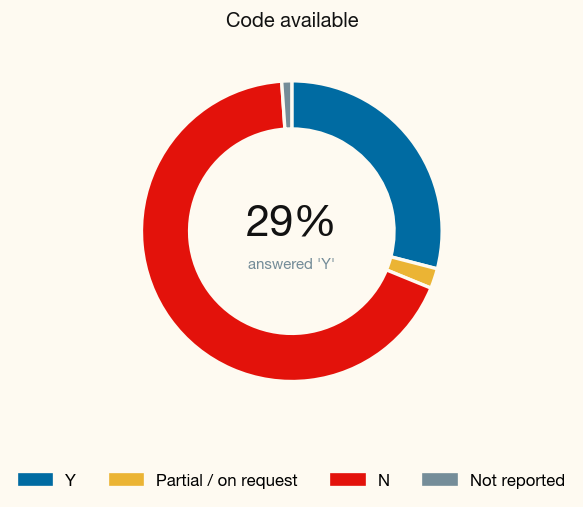

In [187]:
panels = {
    "Code available": code_bucket(df_main["Code available? (Y/N)"]),
}

level_order = ["Y", "Partial / on request", "N", "Not reported"]
level_colors = {
    "Y": ECON["navy"],
    "Partial / on request": ECON["gold"],
    "N": ECON["red"],
    "Not reported": ECON["grey"],
}

fig = plt.figure(figsize=(7.5, 5.4))
axes = [fig.add_axes([0.2, 0.18, 0.6, 0.58])]

for ax, (title, series) in zip(axes, panels.items()):
    counts = series.value_counts().reindex(level_order, fill_value=0)
    total = counts.sum()
    yes_pct = counts["Y"] / total * 100 if total else 0
    wedges, _ = ax.pie(
        counts.values,
        colors=[level_colors[l] for l in counts.index],
        startangle=90, counterclock=False,
        wedgeprops=dict(width=0.32, edgecolor=ECON["paper"], linewidth=2),
    )
    ax.text(0, 0.05, f"{yes_pct:.0f}%", ha="center", va="center",
            fontsize=26, fontweight="bold", color=ECON["ink"])
    ax.text(0, -0.22, "answered 'Y'", ha="center", va="center",
            fontsize=9, color=ECON["grey"])
    ax.set_title(title, fontsize=12, fontweight="bold", color=ECON["ink"], pad=10)

# shared legend
legend_patches = [Rectangle((0, 0), 1, 1, color=level_colors[l]) for l in level_order]
fig.legend(legend_patches, level_order, loc="lower center", ncol=4,
           bbox_to_anchor=(0.5, 0.05), frameon=False, fontsize=10)

_out = FIG_DIR / "fig8_transparency.png"
fig.savefig(_out)
print(f"saved → {_out.resolve()}")
plt.show()


In [192]:
### Static vs dynamic graphs
col = "Graph type (static / dynamic / adaptive / hierarchical)"
vals = df_arch[col].fillna("N/A").astype(str).str.strip()

# count a paper toward BOTH if it used "Static and Dynamic"
is_static  = vals.str.contains("Static",  case=False)
is_dynamic = vals.str.contains("Dynamic", case=False)

n_papers = len(df_arch)
counts = {
    "Static":  int(is_static.sum()),
    "Dynamic": int(is_dynamic.sum()),
    "Not specified / N/A": int((vals.str.upper() == "N/A").sum()),
}

tbl = (
    pd.Series(counts, name="Papers")
    .rename_axis("Graph type")
    .reset_index()
)
tbl["% of papers"] = (tbl["Papers"] / n_papers * 100).round(0).astype(int)

print(tbl.to_string(index=False))
print(f"\n{n_papers} rows in 'Model Architecture' "
      f"(Static + Dynamic exceed the non-N/A total because some papers used both)")

         Graph type  Papers  % of papers
             Static      25           27
            Dynamic      20           22
Not specified / N/A      50           54

93 rows in 'Model Architecture' (Static + Dynamic exceed the non-N/A total because some papers used both)


## Summary table
Quick numerical snapshot for the write-up.

In [193]:
import re
summary = {
    "Included papers": len(df_main),
    "Year range": f"{int(df_main['year'].min())}–{int(df_main['year'].max())}",
    "Peak year": int(df_main['year'].value_counts().idxmax()),
    "Code available (yes)": int((code_bucket(df_main['Code available? (Y/N)']) == 'Y').sum()),
}
pd.Series(summary, name="value").to_frame()


,value
Included papers,93
Year range,2018–2026
Peak year,2022
Code available (yes),27


In [194]:
import re
SOFTWARE_KEYWORDS = {
    "Python": ["python", "pytorch", "tensorflow", "keras", "scikit", "sklearn"],
    "R": ["r studio", "rstudio"],   # bare "r" handled separately below — too ambiguous to substring
    "MATLAB": ["matlab"],
    "QGIS": ["qgis"],
    "ArcGIS": ["arcgis", "arcmap"],
    "Stata": ["stata"],
    "SAS": ["sas"],
    "Julia": ["julia"],
    "C/C++": ["c++", "c/c++"],
}

NOT_REPORTED = ("not mentioned", "doesn't say", "doesnt say", "didn't say",
                "not reported", "not stated", "na", "n/a")

def software_used(raw):
    if pd.isna(raw):
        return ["Not reported"]
    text = str(raw).strip().lower()
    if not text or any(p in text for p in NOT_REPORTED):
        return ["Not reported"]
    # split the cell into tokens so bare "r" can be matched exactly, not as a substring
    tokens = [t.strip() for t in re.split(r"[,/;&]| and ", text) if t.strip()]
    hits = set()
    for fam, kws in SOFTWARE_KEYWORDS.items():
        if any(k in text for k in kws):
            hits.add(fam)
    if "r" in tokens or "r," in tokens:          # exact-token match for R
        hits.add("R")
    # drop obvious non-software tokens like "data"
    hits.discard("")
    return sorted(hits) or ["Other"]

soft = df_main.copy()
soft["Software"] = soft["Software used"].apply(software_used)
soft = soft.explode("Software")

counts = (soft["Software"].value_counts()
          .rename_axis("Software").reset_index(name="Papers"))
print(counts.to_string(index=False))

mask = df_main["Software used"].apply(lambda r: software_used(r) == ["Other"])
print(df_main.loc[mask, "Software used"].value_counts(dropna=False))

    Software  Papers
      Python      49
Not reported      28
           R      13
      MATLAB       3
        QGIS       3
       Other       2
      ArcGIS       1
       Stata       1
Software used
Dones't say    1
Doesn’t sat    1
Name: count, dtype: int64


## Exported figures

All charts are saved as PNGs in **`exported_figures/`** next to this notebook (300 dpi). Run the cell below to print the full path and file list.

In [195]:
out = sorted(FIG_DIR.glob("*.png"))
print(f"Export folder: {FIG_DIR.resolve()}\n")
for p in out:
    print(f"  {p.name}")
print(f"\nTotal: {len(out)} PNG file(s)")

Export folder: /Users/oc25003/scoping-review-figures/exported_figures

  fig1_publications_by_year.png
  fig2_disease_breakdown.png
  fig3_method_category_over_time.png
  fig4_core_architectures.png
  fig5_covariates.png
  fig6_evaluation_metrics.png
  fig7_interpretation.png
  fig8_transparency.png
  fig_countries.png
  fig_disease_temporal_resolution.png
  fig_forecast_horizon_bands.png
  fig_forecast_horizon_by_method.png
  fig_method_explainability_stacked.png
  fig_temporal_resolution_distribution.png

Total: 14 PNG file(s)
